In [1]:
# Standard library
from pathlib import Path
import importlib

# Third-party
import chess.pgn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from sklearn.cluster import HDBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Local
from pgn_to_df import parser

In [2]:
# Paths
DIR = Path.cwd().parent / "data"
INPUT_PATH = DIR / "lichess_db_standard_rated_2013-02.pgn"
OUTPUT_PATH = DIR / "sr_2013_02.csv"

In [3]:
INPUT_PATH

WindowsPath('c:/Users/foghd/Documents/GitHub/AppML_FinalProject/root/workspace/data/lichess_db_standard_rated_2013-02.pgn')

In [ ]:
"C:\Users\foghd\Documents\GitHub\AppML_FinalProject\root\data\lichess_db_standard_rated_2013-02.pgn"

In [3]:
if OUTPUT_PATH.exists():
    df = pd.read_csv(OUTPUT_PATH)
else:
    df = parser(INPUT_PATH)
    df.to_csv(OUTPUT_PATH, index=False)

df.head()

,event,site,white,black,result,date,time,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_halfmoves,num_moves
0,Rated Classical game,https://lichess.org/9tp6v4ps,Smok,McCoy,1-0,2013.01.31,23:01:50,1452,1227,5,-20,B01,Scandinavian Defense,480+0,Time forfeit,33,16.5
1,Rated Blitz game,https://lichess.org/b9tstv2z,dvorak,Kiriush,1-0,2013.01.31,23:03:05,1796,1876,13,-14,C55,"Italian Game: Two Knights Defense, Perreux Var...",180+0,Normal,43,21.5
2,Rated Bullet game,https://lichess.org/azjm2dih,Greenlan,chrisstansell,1-0,2013.01.31,23:00:17,1650,1534,8,-8,A00,Mieses Opening,0+1,Time forfeit,3,1.5
3,Rated Blitz game,https://lichess.org/yfe3lngr,Magus,Tsoomoo,1-0,2013.01.31,23:02:26,1807,1637,7,-6,C41,Philidor Defense: Larsen Variation,300+0,Time forfeit,71,35.5
4,Rated Classical game,https://lichess.org/xslxnflt,philidor,Goofy,1-0,2013.01.31,23:01:34,1457,1442,11,-15,B01,Scandinavian Defense: Mieses-Kotroc Variation,900+0,Normal,13,6.5


NOTE:
* Parsing took approx 2 min: 30 sek for approx 150K games - need to be sped up quite a lot.
* Specific sequence of moves not included in each game not included. It is mostly game metadata.

In [5]:
numeric_features = [
    "white_elo",
    "black_elo",
    "white_rating_diff",
    "black_rating_diff",
    "num_halfmoves",
    "num_moves",
]

categorical_features = [
    "event",
    "result",
    "eco",
    "opening",
    "time_control",
    "termination",
]

array([[<Axes: title={'center': 'white_elo'}>,
        <Axes: title={'center': 'black_elo'}>],
       [<Axes: title={'center': 'white_rating_diff'}>,
        <Axes: title={'center': 'black_rating_diff'}>],
       [<Axes: title={'center': 'num_halfmoves'}>,
        <Axes: title={'center': 'num_moves'}>]], dtype=object)

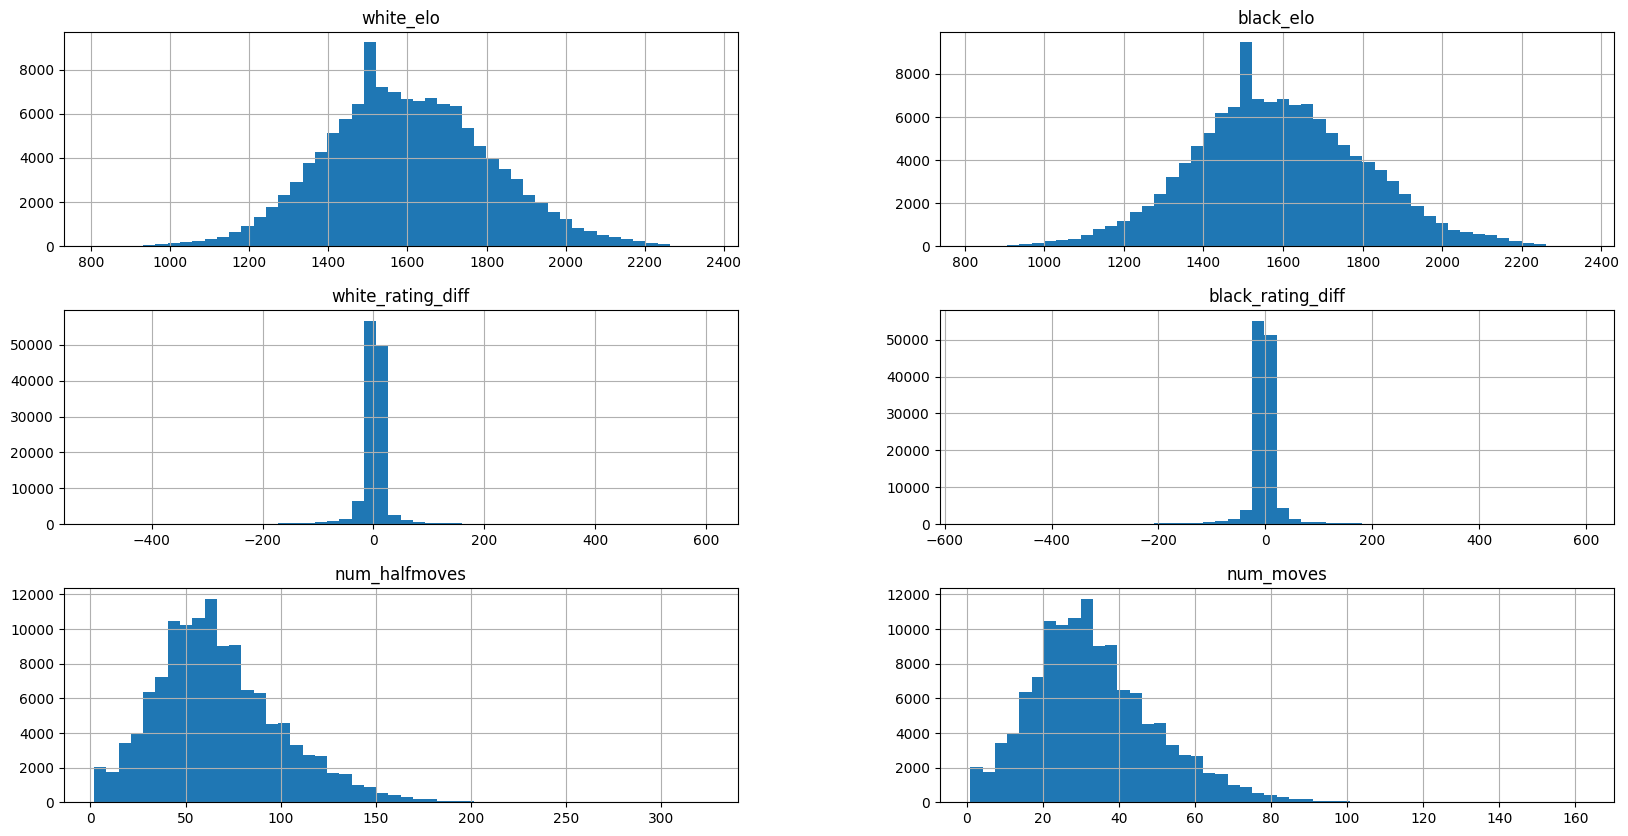

In [6]:
# Plot all numeric features in df
df[numeric_features].hist(bins=50, figsize=(20, 10))

KeyboardInterrupt: 

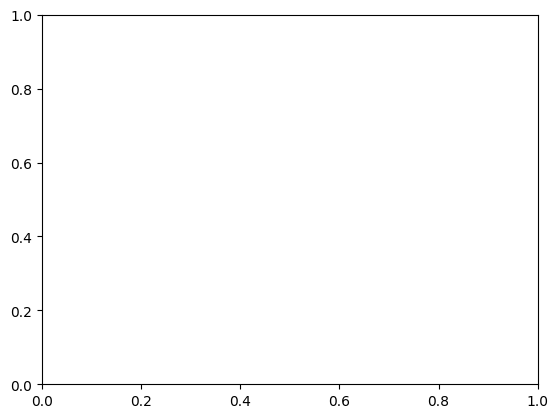

In [27]:

# print the elo for the bin with the highest count
def plot_elo_histogram(df):
    plt.hist(df["white_elo"], bins=50000, alpha=0.5, label="White Elo", color="blue")
    plt.hist(df["black_elo"], bins=50000, alpha=0.5, label="Black Elo", color="red")
    plt.xlabel("Elo Rating")
    plt.ylabel("Count")
    plt.title("Distribution of Elo Ratings")
    plt.legend()
    plt.show()


plot_elo_histogram(df)



# count frequencies in each bin, return elo for bin with highest count
def get_most_common_elo(df):
    white_hist, white_bins = np.histogram(df["white_elo"], bins=50000)
    black_hist, black_bins = np.histogram(df["black_elo"], bins=50000)

    most_common_white_elo = white_bins[np.argmax(white_hist)]
    most_common_black_elo = black_bins[np.argmax(black_hist)]

    return most_common_white_elo, most_common_black_elo

most_common_white_elo, most_common_black_elo = get_most_common_elo(df)
print(f"Most common White Elo: {most_common_white_elo}")
print(f"Most common Black Elo: {most_common_black_elo}")

